# 15.1.1 从计算图到小型神经网络

## 学习目标与先修知识

写出一层标量网络的前向计算，并逐项解释参数（parameter）、激活和损失。

先修：8.2 梯度（gradient）与链式法则（chain rule）；基本 Python 函数、指数函数（exponential function）。

## 具体问题

只观测（observation）到某种清除响应随状态（state）变化的少量点。用一个平滑神经元近似输入（input）到响应的映射时，哪些量是状态、哪些量是待学习参数？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
for x in [-1.,0.,1.]: print(x, .8*np.tanh(1.2*x-.2)+.1)

-1.0 -0.60828131856181
0.0 -0.0579002561799232
1.0 0.7092753247646119


## 模型假设

此处 x 是以 U 为单位的数值，网络输入实际是 x/(1 U)；w、b 作用在无量纲（dimensionless）输入上，v、c 的单位是响应单位。本节只拟合静态映射，不把它直接叫作微分方程。

## 数学解释与推导

计算图（computational graph）按 $z=wx+b$、$a=\tanh z$、$\hat y=va+c$、$L=\frac12(\hat y-y)^2$ 排列。每个节点只保存当前数值及其父节点。复合函数的导数（derivative）沿相反方向传递；一个参数被多条路径共用时，来自各路径的梯度相加。此处的 $\tanh$ 有导数 $1-\tanh^2z$。网络是函数表示，数据拟合本身不揭示生理机制。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def scalar_net(x, w, b, v, c):
    return float(v * math.tanh(w * x + b) + c)


def scalar_loss_grad(x, y, w, b, v, c):
    z = w * x + b
    a = math.tanh(z)
    prediction = v * a + c
    error = prediction - y
    factor = error * v * (1 - a * a)
    return prediction, .5 * error * error, [factor * x, factor, error * a, error]

## 对照实验

改变已声明的条件并比较曲线与数值。

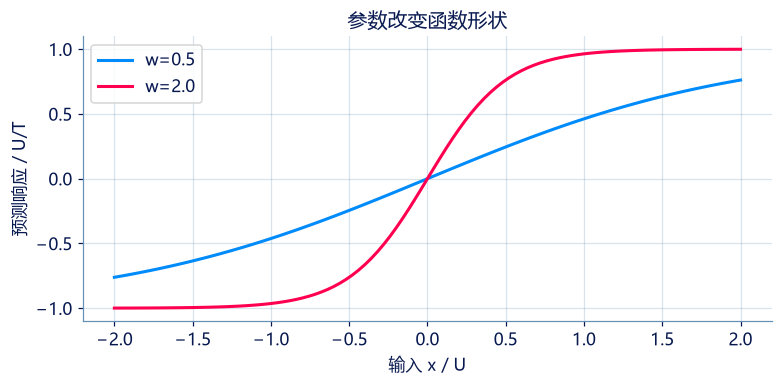

x=1 的损失与梯度： (0.7092753247646119, 0.021898080777666883, [0.0703122133872635, 0.0703122133872635, 0.15938286432647314, 0.20927532476461186])


In [4]:
xs=np.linspace(-2,2,101)
fig,ax=plt.subplots(figsize=(7,3.4))
for w,color in [(.5,BLUE),(2.,PINK)]:ax.plot(xs,[scalar_net(x,w,0.,1.,0.) for x in xs],label=f"w={w}",color=color)
ax.set(xlabel="输入 x / U",ylabel="预测响应 / U/T",title="参数改变函数形状");ax.legend();ax.grid(alpha=.25);plt.show()
print("x=1 的损失与梯度：",scalar_loss_grad(1.,.5,1.2,-.2,.8,.1))

## 结果解释

较大的 w 使过渡更陡，但这只是所选函数族的形状变化。预测、目标与损失必须在相同单位下解释；平方损失单位为响应单位的平方。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
def scalar_net(x, w, b, v, c):
    return float(v * math.tanh(w * x + b) + c)


def finite_difference_grad(x, y, w, b, v, c, h):
    values = [w, b, v, c]
    gradients = []
    for j in range(4):
        plus, minus = values.copy(), values.copy()
        plus[j] += h
        minus[j] -= h
        lp = .5 * (scalar_net(x, *plus) - y)**2
        lm = .5 * (scalar_net(x, *minus) - y)**2
        gradients.append((lp - lm) / (2*h))
    return gradients

In [6]:
pred,loss,grad=scalar_loss_grad(1.,.5,1.2,-.2,.8,.1)
assert abs(pred-scalar_net(1.,1.2,-.2,.8,.1))<1e-14
assert abs(loss-.5*(pred-.5)**2)<1e-14
np.testing.assert_allclose(grad,finite_difference_grad(1.,.5,1.2,-.2,.8,.1,1e-5),rtol=1e-8,atol=1e-9)
print("独立中心差分与损失恒等式通过。")

独立中心差分与损失恒等式通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：计算图的前向顺序

对于 z=wx+b、a=tanh(z)、预测 va+c、平方损失，哪一步必须先于激活值？

- **A.** 计算 z。
- **B.** 计算损失。
- **C.** 更新权重。
- **D.** 查看留出答案。

[作答：计算图的前向顺序](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-graph-order)

### 第 2 题 · 单项选择题：网络表示的对象

只把 x 输入（input）静态网络并得到响应率，哪项解释最准确？

- **A.** 网络已经给出任意时间的状态（state）轨迹（trajectory）。
- **B.** 它表示给定输入下的函数值，若作为动力学右端还需方程与求解器。
- **C.** 它自动保证总量守恒。
- **D.** 参数（parameter）值直接等于真实清除机制。

[作答：网络表示的对象](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-static-not-ode)

### 第 3 题 · Python 计算题：计算一神经元响应

按 tanh 网络返回给定输入（input）的预测。

**函数与代码模板**

```python
def solve(
    x: float,
    w: float,
    b: float,
    v: float,
    c: float,
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 以 U 为单位的输入数值。 | U |
| `w` | `float` | 无量纲（dimensionless）输入系数。 | 1 |
| `b` | `float` | 激活偏置。 | 1 |
| `v` | `float` | 激活的输出（output）幅度。 | U/T |
| `c` | `float` | 输出偏置。 | U/T |

**返回值**

直接返回 prediction（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prediction` | `float` | 给定输入的响应预测。 | U/T |

**计算规则**

预测 = v*tanh(w*x+b)+c。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 以 U 为单位的输入数值。 | 0 | U |
| w | 无量纲（dimensionless）输入系数。 | 1 | 1 |
| b | 激活偏置。 | 0 | 1 |
| v | 激活的输出（output）幅度。 | 2 | U/T |
| c | 输出偏置。 | 0.3 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.0
w = 1.0
b = 0.0
v = 2.0
c = 0.3

result = solve(x, w, b, v, c)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| prediction | 给定输入的响应预测。 | 0.3 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.3
```

**样例解释**

先算 z=wx+b，再算 v tanh(z)+c。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算一神经元响应](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-network-value)

### 第 4 题 · Python 计算题：输出、损失与四个梯度

按 w,b,v,c 顺序返回预测、半平方损失和梯度（gradient）。

**函数与代码模板**

```python
def solve(
    x: float,
    y: float,
    w: float,
    b: float,
    v: float,
    c: float,
) -> tuple[float, float, list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 输入（input）数值。 | U |
| `y` | `float` | 目标响应。 | U/T |
| `w` | `float` | 输入权重。 | 1 |
| `b` | `float` | 激活偏置。 | 1 |
| `v` | `float` | 输出（output）幅度。 | U/T |
| `c` | `float` | 输出偏置。 | U/T |

**返回值**

按以下顺序返回元组：(prediction, loss, gradient)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `prediction` | `float` | 网络预测。 | U/T |
| `loss` | `float` | 半平方误差。 | (U/T)^2 |
| `gradient` | `list[float]` | 依次对 w,b,v,c 的偏导数（partial derivative）值。 | 按参数 |

**计算规则**

预测同上，损失 = (预测-y)²/2；梯度按 w,b,v,c 顺序。

**约束与边界**

- 输入规模不超过100，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 输入（input）数值。 | 0 | U |
| y | 目标响应。 | 1 | U/T |
| w | 输入权重。 | 1 | 1 |
| b | 激活偏置。 | 0 | 1 |
| v | 输出（output）幅度。 | 2 | U/T |
| c | 输出偏置。 | 0 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.0
y = 1.0
w = 1.0
b = 0.0
v = 2.0
c = 0.0

result = solve(x, y, w, b, v, c)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| prediction | 网络预测。 | 0 | U/T |
| loss | 半平方误差。 | 0.5 | (U/T)^2 |
| gradient | 依次对 w,b,v,c 的偏导数（partial derivative）值。 | [-0.0, -2.0, -0.0, -1.0] | 按参数 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, 0.5, [-0.0, -2.0, -0.0, -1.0])
```

**样例解释**

x=0、b=0 时 tanh=0；检查 w 梯度仍须经链式法则（chain rule）。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：输出、损失与四个梯度](http://127.0.0.1:8000/chapters/15-01-%E7%A5%9E%E7%BB%8F%E7%BD%91%E7%BB%9C%E4%B8%8E%E8%87%AA%E5%8A%A8%E5%BE%AE%E5%88%86/practice/?question=p15-network-loss-gradient)

**进一步阅读**

[Baydin 等的自动微分综述](https://jmlr.org/papers/volume18/17-468/17-468.pdf)；本节计算图为可手算教学例。